In [1]:
"""
Created on Fri Mar 28 16:02:45 2025

@author: danielsaavedramorales
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from statsmodels.distributions.empirical_distribution import ECDF


# 1. Leer los datos y análisis descriptivo

In [2]:

# Asumo que los datos tienen columnas: Meses, Censura (1=evento, 0=censura)

data = pd.read_table("datos1_falla_ISSN 0120-1751.txt", delim_whitespace=True)

# Porcentaje de censura
perc_censura = 1 - data['Censura'].mean()
print(f"Porcentaje de censura: {perc_censura:.2%}\n")

# Resumen estadístico
print("Resumen estadístico de Meses:")
print(data['Meses'].describe())
print(f"\nDesviación estándar: {data['Meses'].std():.2f}")
# =============================================================================
# 
# =============================================================================


Porcentaje de censura: 76.39%

Resumen estadístico de Meses:
count    72.000000
mean     59.691250
std      14.227181
min      14.070000
25%      66.000000
50%      66.000000
75%      66.000000
max      66.000000
Name: Meses, dtype: float64

Desviación estándar: 14.23


# 2. Análisis gráfico inicial

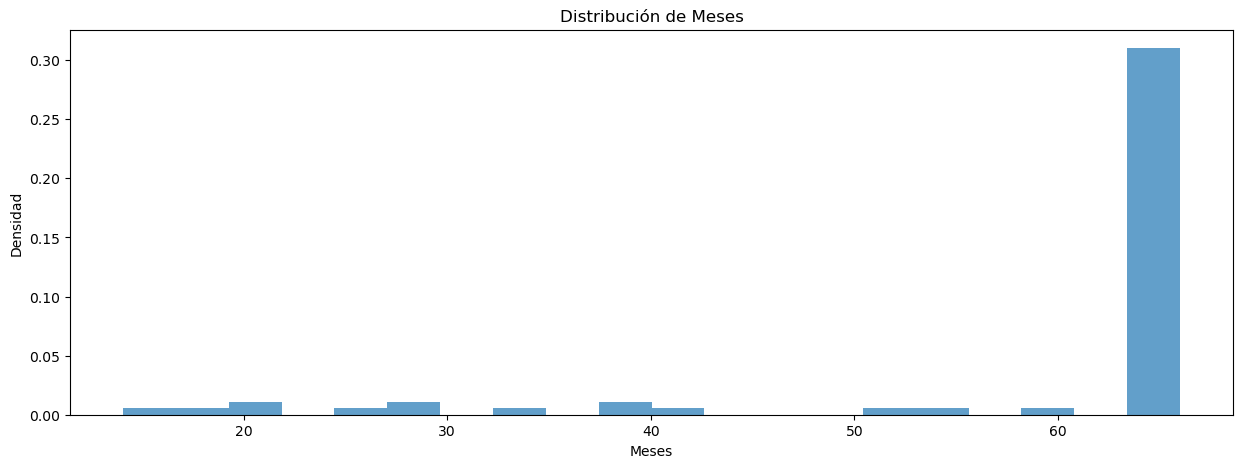

Text(0, 0.5, 'Probabilidad Acumulada')

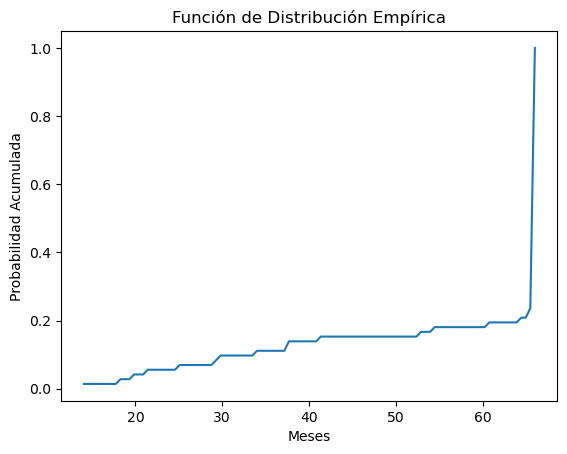

In [3]:

plt.figure(figsize=(15, 5))

# Histograma

plt.title('Distribución de Meses')
plt.xlabel('Meses')
plt.ylabel('Densidad')
plt.hist(data['Meses'], density=True,bins=20, alpha=0.7)
plt.show()

# Función de distribución empírica

empirical_cdf = ECDF(data['Meses'])
x = np.linspace(min(data['Meses']), max(data['Meses']), 100)
plt.plot(x, empirical_cdf(x))
plt.title('Función de Distribución Empírica')
plt.xlabel('Meses')
plt.ylabel('Probabilidad Acumulada')


# 3. Análisis de Kaplan-Meier

<Axes: xlabel='timeline'>

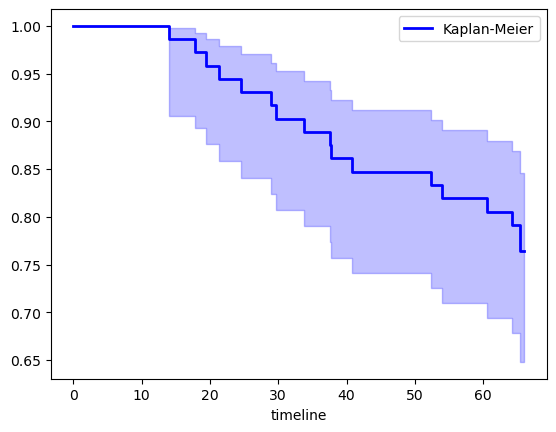

In [4]:


kmf = KaplanMeierFitter()
kmf.fit(data['Meses'], event_observed=data['Censura'], label='Kaplan-Meier')
kmf.plot(color='blue', linewidth=2)


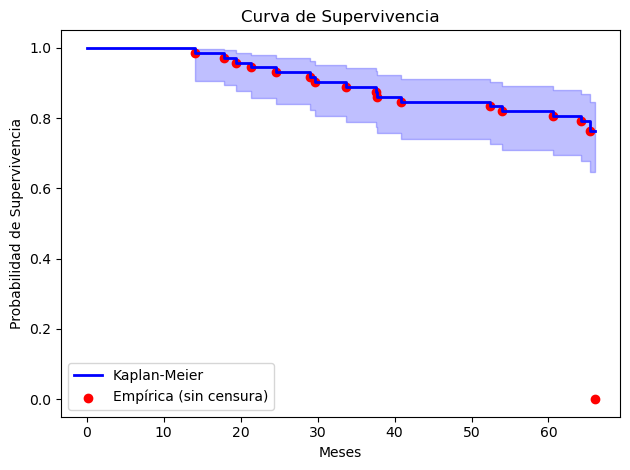


Estimación de Kaplan-Meier:
          Kaplan-Meier
timeline              
0.00          1.000000
14.07         0.986111
17.80         0.972222
19.43         0.958333
21.33         0.944444
24.60         0.930556
28.97         0.916667
29.63         0.902778
33.73         0.888889
37.60         0.875000
37.67         0.861111
40.87         0.847222
52.40         0.833333
53.97         0.819444
60.57         0.805556
64.27         0.791667
65.43         0.763889
66.00         0.763889

Mediana de supervivencia: inf meses


In [6]:

kmf = KaplanMeierFitter()
kmf.fit(data['Meses'], event_observed=data['Censura'], label='Kaplan-Meier')
kmf.plot(color='blue', linewidth=2)

# Supervivencia empírica (sin censura)
times = np.sort(data['Meses'].unique())
surv_prob = 1 - empirical_cdf(times)
plt.scatter(times, surv_prob, color='red', label='Empírica (sin censura)')

plt.title('Curva de Supervivencia')
plt.xlabel('Meses')
plt.ylabel('Probabilidad de Supervivencia')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 4. Resultados de Kaplan-Meier
print("\nEstimación de Kaplan-Meier:")
print(kmf.survival_function_)

# Mediana de supervivencia
median_survival = kmf.median_survival_time_
print(f"\nMediana de supervivencia: {median_survival:.2f} meses")
